# PoTeC decoder-LM pipeline (steps 1–6)
Thin driver over the `src/` modules: reading-time cleaning, causal-LM surprisal,
attention (raw + flow), DAPT fine-tuning, and the surprisal/attention vs gaze
analysis. Run from the project root.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
from src import data, reading_time as rt, surprisal as su, attention as at, analysis as an, viz
MEASURE = 'TFT'  # total fixation time == TRT

## Step 1 — reading time

In [2]:
words = data.load_word_features()
rm_raw = data.load_reading_measures()
rm = rt.clean_reading_times(rm_raw, MEASURE)
print(f'words={len(words)}  raw_rows={len(rm_raw)}  cleaned={len(rm)} ({len(rm)/len(rm_raw):.1%})')
agg = rt.aggregate_rt(rm, MEASURE)
{k: (len(v), round(v[f'mean_{MEASURE}'].mean())) for k, v in agg.items()}

words=1895  raw_rows=142125  cleaned=109708 (77.2%)


{'all': (1701, 604), 'experts': (1701, 559), 'experts_graduate': (1701, 559)}

## Step 2 — model surprisal (baseline)

In [3]:
model, tok = su.load_causal_lm()
surp = su.compute_surprisal(words, model, tok)  # prompt=None; pass a {domain: str} dict for domain-matched prompting
surp.head()

,text_id,word_index_in_text,surprisal
0,b0,2,6.670333
1,b0,3,11.624302
2,b0,4,3.556032
3,b0,5,37.965656
4,b0,6,9.998916


## Step 3 — attention (raw on full corpus; flow is heavier, run on a subset)

In [4]:
amodel, atok = su.load_causal_lm(attn=True)
attn_raw = at.extract_attention(words, amodel, atok, method='raw')
# attn_flow = at.extract_attention(words[words.text_id.isin(['b0','p0'])], amodel, atok, method='flow')
et = an.build_et_table(rm_raw, domain='all', participants='all')
attn_raw.shape, et.shape

/home/ely/.local/share/mamba/envs/eyebench/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


((20412, 5), (1895, 11))

## Step 5 — analysis

In [5]:
merged = an.merge_surprisal_rt(surp, rm)
rows = []
for grp in ['all', 'experts', 'novices']:
    for dom_only in (False, True):
        r = an.correlate_surprisal(merged, participants=grp, domain_only=dom_only, mode='mean')
        rows.append({'group': grp, 'domain_only': dom_only, **r})
pd.DataFrame(rows)[['group','domain_only','n','pearson','spearman']]

,group,domain_only,n,pearson,spearman
0,all,False,1696,0.695662,0.597525
1,all,True,375,0.648665,0.610004
2,experts,False,1696,0.659994,0.560105
3,experts,True,375,0.603941,0.554118
4,novices,False,1696,0.695852,0.601331
5,novices,True,375,0.649526,0.621629


slope=38.79 ms/bit  R2=0.484


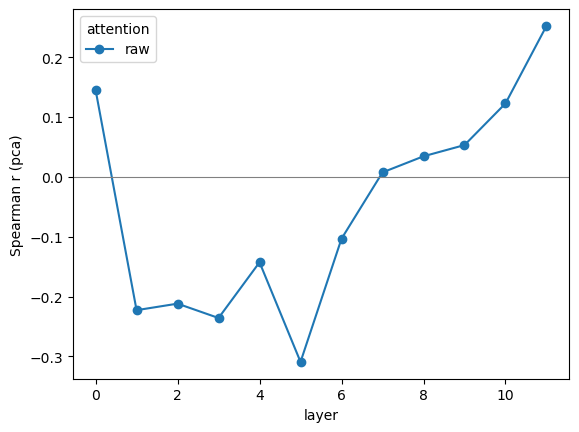

In [6]:
fit = an.regress_rt(merged, participants='all')
print(f"slope={fit.params['surprisal']:.2f} ms/bit  R2={fit.rsquared:.3f}")
corr = an.correlate_attention(attn_raw, et, attention_method='raw')
ax = viz.attention_layer_curve(corr, feature='pca')

## Step 4 — DAPT fine-tuning (run separately; GPU recommended)
Trains the baseline independently on the physics / biology `german-commons`
splits, checkpointing every 10 epochs with a perplexity curve. `max_docs` /
small `epochs` for a quick local check; drop them for a real run.

In [ ]:
from src import finetune as ft
# manifest = ft.finetune_dapt('physics', epochs=30, save_every=10)
# surp_versions = ft.recompute_surprisal_over_checkpoints(words, manifest)
# viz.perplexity_curve(manifest)

### Correlation vs fine-tuning epoch (experts vs non-experts)
Pearson r of surprisal vs reading time at each checkpoint, one line per reader
group. `DOMAIN_ONLY=True` restricts to technical-term words; set `False` for all
words.

In [ ]:
DOMAIN_ONLY = True
# curve = an.correlation_over_epochs(surp_versions, rm, domain_only=DOMAIN_ONLY, mode='mean')
# viz.finetune_correlation_curve(curve, metric='pearson')